In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# Load data dan encode variabel kategorikal
df = pd.read_csv('../data/college.csv')

le = LabelEncoder()
df['Gender_encoded'] = le.fit_transform(df['Gender'])
df['Encourage_encoded'] = le.fit_transform(df['Encourage'])
df['Plan_encoded'] = le.fit_transform(df['Plan'])

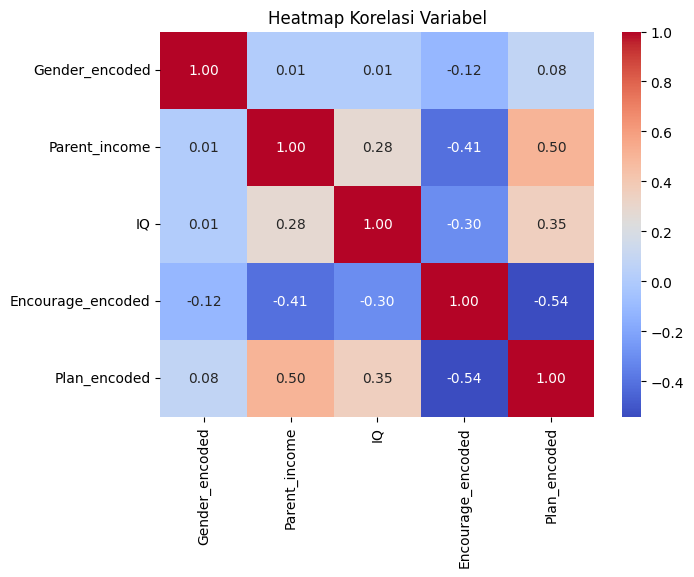

KORELASI DENGAN TARGET 'PLAN'
Parent_income        :  0.501
IQ                   :  0.354
Gender_encoded       :  0.083
Encourage_encoded    : -0.541


In [3]:
# Analisis Perbandingan Plan vs Not Plan
corr_data = df[['Gender_encoded', 'Parent_income', 'IQ', 'Encourage_encoded', 'Plan_encoded']]
corr_matrix = corr_data.corr()

# Tampilkan heatmap korelasi
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Korelasi Variabel")
plt.show()

# Cetak korelasi terhadap target 'Plan_encoded'
print("=" * 60)
print("KORELASI DENGAN TARGET 'PLAN'")
print("=" * 60)
correlations = corr_matrix['Plan_encoded'].drop('Plan_encoded').sort_values(ascending=False)
for feat, corr in correlations.items():
    print(f"{feat:<20} : {corr:>6.3f}")

In [4]:
# Siapkan fitur (X) dan target (y)
X = df[['Gender_encoded', 'Parent_income', 'IQ', 'Encourage_encoded']]
y = df['Plan_encoded']

In [5]:
# Bagi data training (80%) dan testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Buat dan latih model decision tree
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [6]:
# Evaluasi model
y_pred = model.predict(X_test)

print("\n" + "=" * 60)
print("HASIL KEPUTUSAN MODEL")
print("=" * 60)
print(f"Akurasi Model : {accuracy_score(y_test, y_pred):.3f}\n")
print("Laporan Klasifikasi:")
print(classification_report(y_test, y_pred))


HASIL KEPUTUSAN MODEL
Akurasi Model : 0.851

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.87      0.92      0.89      1093
           1       0.80      0.71      0.75       507

    accuracy                           0.85      1600
   macro avg       0.84      0.81      0.82      1600
weighted avg       0.85      0.85      0.85      1600



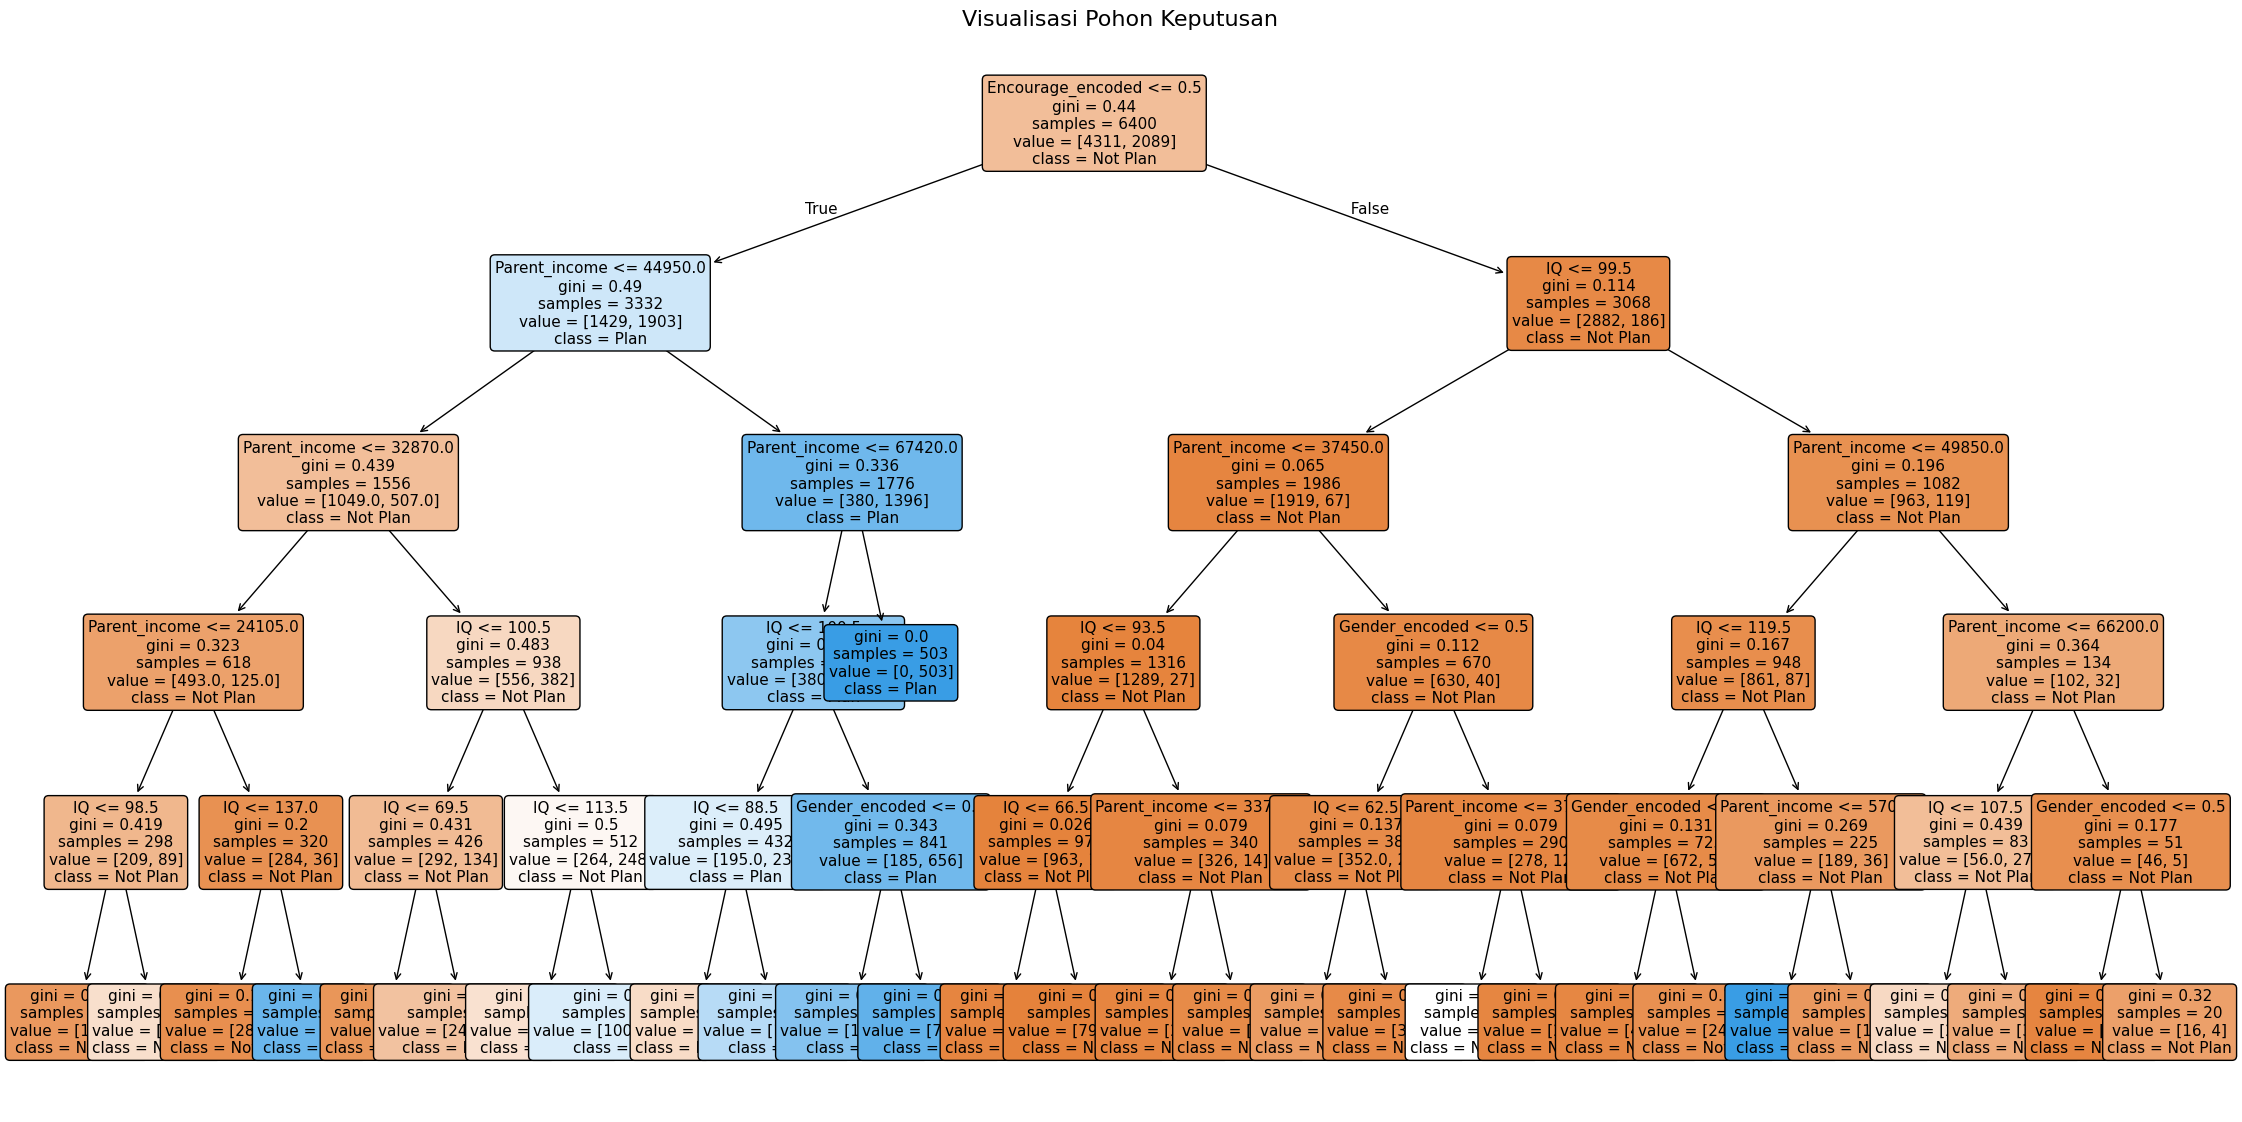

In [12]:
plt.figure(figsize=(28, 14))  
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Not Plan', 'Plan'],
    filled=True,
    rounded=True,
    fontsize=11
)
plt.title("Visualisasi Pohon Keputusan ", fontsize=16)
plt.show()
